# Customer Segmentation using Naive Bayes Algorithms
## End-to-End Modular Machine Learning Pipeline (7 Stages)

**Author:** Google Antigravity Agent  
**Dataset:** Customer Segmentation Dataset (`segmentation data.csv`)  
**Objective:** Discover natural customer segments via unsupervised clustering, then build, tune, evaluate, compare, and deploy modular Naive Bayes classification pipelines alongside baseline models to classify customer personas accurately.

---

### Pipeline Overview:
1. **Stage 1: Data and Library Import** - Setup environment, import `src/` modules, load raw dataset.
2. **Stage 2: Exploratory Data Analysis (EDA)** - Distributions, correlations, and K-Means + PCA customer segment discovery.
3. **Stage 3: Data Preprocessing & Modular Pipelines** - Feature engineering, train/test split, `ColumnTransformer` pipelines.
4. **Stage 4: Model Building** - Pipeline assembly for **GaussianNB**, **CategoricalNB**, **BernoulliNB**, **ComplementNB**, and 5 comparison algorithms.
5. **Stage 5: Hyperparameter Tuning** - Systematic tuning using `GridSearchCV` on pipeline parameters.
6. **Stage 6: Model Evaluation & Comparison** - Quantitative metrics table (Accuracy, Precision, Recall, F1, ROC-AUC).
7. **Stage 7: Visualization of Results & Artifact Saving** - Performance charts, confusion matrices, ROC curves, `.joblib` serialization, and inference verification.


---
## Stage 1: Data and Library Import

We load essential scientific computing libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`) and our modular backend scripts (`src/`).


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add workspace path
sys.path.append(os.getcwd())

# Import custom modular components
from src.data import load_raw_data, discover_customer_segments
from src.preprocessing import split_customer_data, create_standard_preprocessor
from src.models import build_model_pipelines, get_hyperparameter_grids
from src.evaluation import (
    compute_model_metrics, build_comparison_dataframe,
    plot_model_comparison, plot_confusion_matrices,
    plot_multiclass_roc, plot_pca_clusters
)
from src.utils import (
    save_pipeline_artifact, load_pipeline_artifact,
    save_metrics_json, predict_single_customer
)

# Global plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"

# Load raw customer data
df_raw = load_raw_data('segmentation data.csv')
print(f"Dataset shape: {df_raw.shape}")
df_raw.head()


Dataset shape: (2000, 8)


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


---
## Stage 2: Exploratory Data Analysis (EDA) & Customer Segment Discovery

We explore summary statistics, verify zero missing values, plot feature distributions, and discover natural customer personas using unsupervised K-Means clustering & Principal Component Analysis (PCA).


--- Missing Values ---
ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64

--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
ID,2000.0,1.000010e+08,577.494589,100000001.0,1.000005e+08,100001000.5,1.000015e+08,100002000.0
Sex,2000.0,4.570000e-01,0.498272,0.0,0.000000e+00,0.0,1.000000e+00,1.0
Marital status,2000.0,4.965000e-01,0.500113,0.0,0.000000e+00,0.0,1.000000e+00,1.0
Age,2000.0,3.590900e+01,11.719402,18.0,2.700000e+01,33.0,4.200000e+01,76.0
Education,2000.0,1.038000e+00,0.599780,0.0,1.000000e+00,1.0,1.000000e+00,3.0
Income,2000.0,1.209544e+05,38108.824679,35832.0,9.766325e+04,115548.5,1.380722e+05,309364.0
Occupation,2000.0,8.105000e-01,0.638587,0.0,0.000000e+00,1.0,1.000000e+00,2.0
Settlement size,2000.0,7.390000e-01,0.812533,0.0,0.000000e+00,1.0,1.000000e+00,2.0


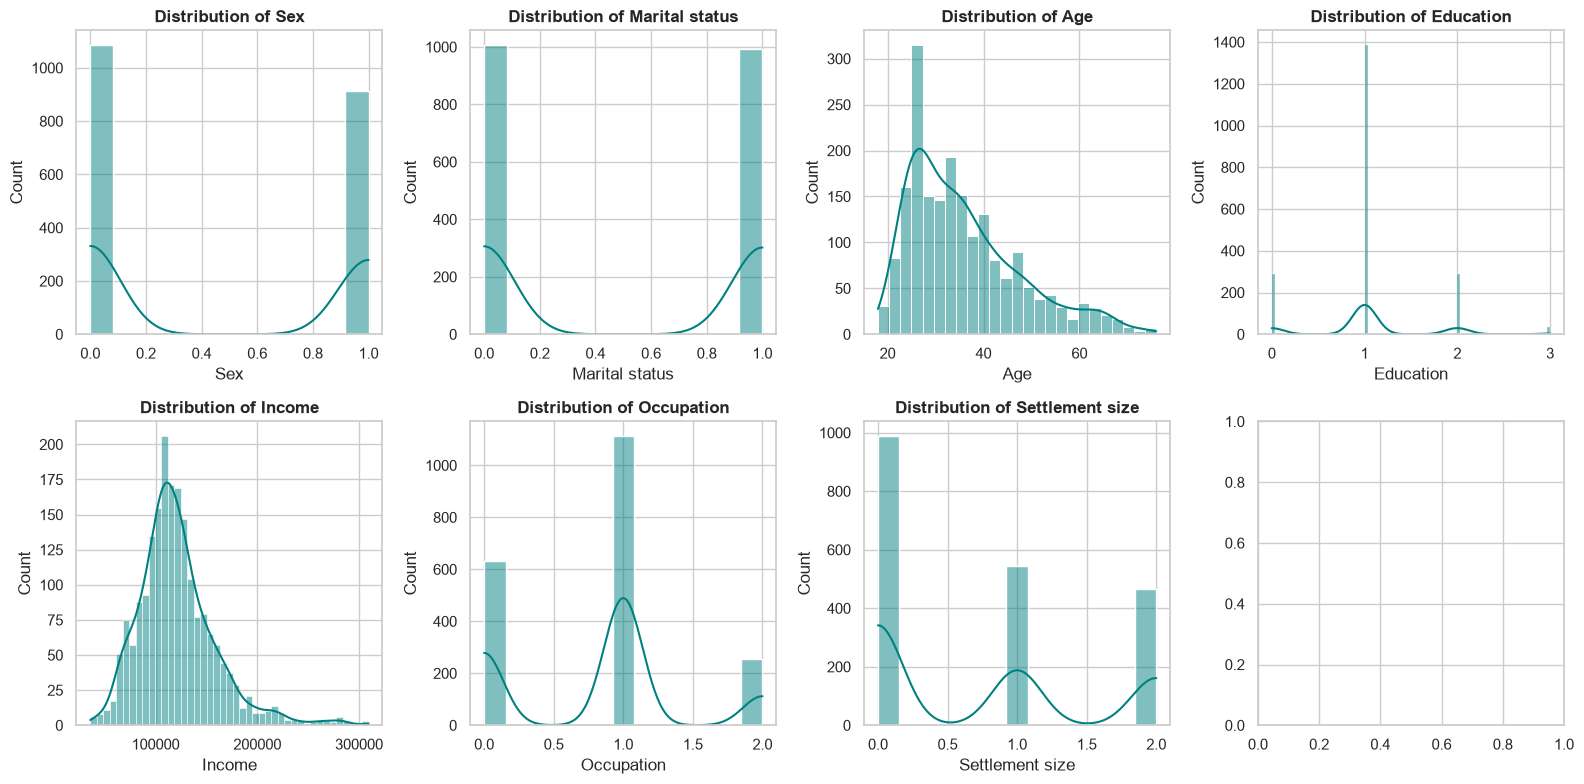


--- Discovered Customer Segment Distributions ---


Segment_Label
Fewer Opportunities    705
Standard               570
Career-Focused         462
Well-Off               263
Name: count, dtype: int64

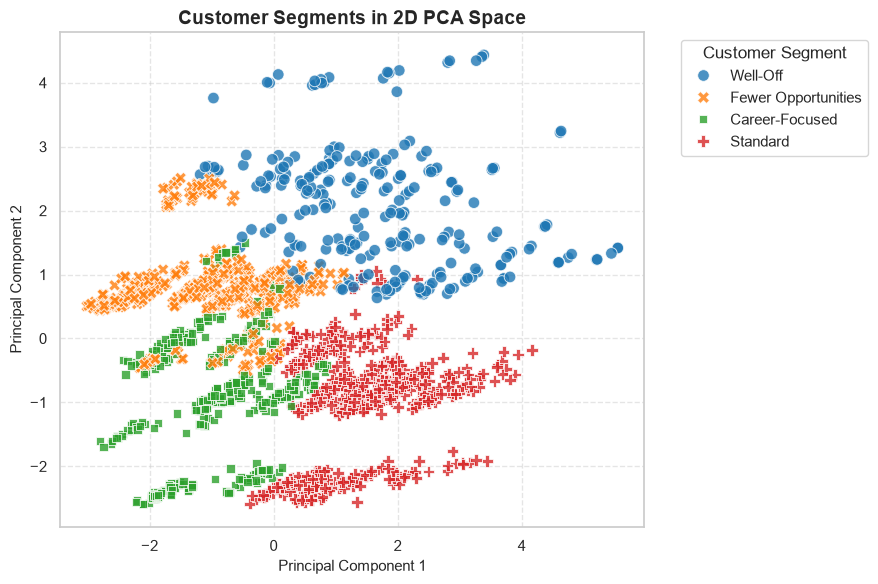

In [2]:
# Summary Statistics
print("--- Missing Values ---")
print(df_raw.isnull().sum())
print("\n--- Summary Statistics ---")
display(df_raw.describe().T)

# Feature Distribution Plots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
features = [c for c in df_raw.columns if c != 'ID']

for idx, col in enumerate(features):
    ax = axes[idx // 4, idx % 4]
    sns.histplot(df_raw[col], kde=True, ax=ax, color='teal')
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    
plt.tight_layout()
plt.show()

# Perform Unsupervised Customer Segmentation (K=4)
df_segmented, kmeans_model, scaler_model, pca_model = discover_customer_segments(df_raw, n_clusters=4)

print("\n--- Discovered Customer Segment Distributions ---")
display(df_segmented['Segment_Label'].value_counts())

# Plot Customer Segments in 2D PCA Space
plot_pca_clusters(df_segmented);


---
## Stage 3: Data Preprocessing & Modular Pipelines

We separate the features (`Age`, `Income`, `Sex`, `Marital status`, `Education`, `Occupation`, `Settlement size`) and target (`Segment`), and perform a stratified 80/20 train/test split.
We use Scikit-Learn `ColumnTransformer` pipelines to preprocess continuous vs categorical features.


In [3]:
# Train / Test Split
X_train, X_test, y_train, y_test = split_customer_data(df_segmented, target_col='Segment', test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print("\nTarget Class Distribution in Train Set:")
print(y_train.value_counts(normalize=True))


X_train shape: (1600, 7)
X_test shape:  (400, 7)

Target Class Distribution in Train Set:
Segment
0    0.35250
1    0.28500
2    0.23125
3    0.13125
Name: proportion, dtype: float64


---
## Stage 4: Model Building

We instantiate modular Scikit-Learn `Pipeline` architectures for 4 Naive Bayes variants and 5 benchmark comparison models:
1. **Gaussian Naive Bayes** (`GaussianNB`)
2. **Categorical Naive Bayes** (`CategoricalNB`)
3. **Bernoulli Naive Bayes** (`BernoulliNB`)
4. **Complement Naive Bayes** (`ComplementNB`)
5. **Logistic Regression**
6. **Random Forest**
7. **Decision Tree**
8. **Support Vector Machine (SVC)**
9. **K-Nearest Neighbors (KNN)**


In [4]:
# Build raw model pipelines
raw_pipelines = build_model_pipelines(random_state=42)

print(f"Successfully constructed {len(raw_pipelines)} model pipelines:")
for name in raw_pipelines:
    print(f"  [+] Pipeline: {name}")


Successfully constructed 9 model pipelines:
  [+] Pipeline: Gaussian Naive Bayes
  [+] Pipeline: Categorical Naive Bayes
  [+] Pipeline: Bernoulli Naive Bayes
  [+] Pipeline: Complement Naive Bayes
  [+] Pipeline: Logistic Regression
  [+] Pipeline: Random Forest
  [+] Pipeline: Decision Tree
  [+] Pipeline: Support Vector Machine
  [+] Pipeline: K-Nearest Neighbors


---
## Stage 5: Hyperparameter Tuning

We execute 5-fold cross-validation hyperparameter optimization using `GridSearchCV` on pipeline parameters (such as `var_smoothing` for GaussianNB and `alpha` for discrete Naive Bayes variants).


In [5]:
from sklearn.model_selection import GridSearchCV

param_grids = get_hyperparameter_grids()
tuned_pipelines = {}
best_params_report = {}

for name, pipeline in raw_pipelines.items():
    grid_params = param_grids.get(name, {})
    if grid_params:
        search = GridSearchCV(
            pipeline, param_grid=grid_params, cv=5, scoring='f1_weighted', n_jobs=-1
        )
        search.fit(X_train, y_train)
        tuned_pipelines[name] = search.best_estimator_
        best_params_report[name] = {
            'Best Params': str(search.best_params_),
            'Best CV F1-Score': round(search.best_score_, 4)
        }
    else:
        pipeline.fit(X_train, y_train)
        tuned_pipelines[name] = pipeline
        best_params_report[name] = {'Best Params': 'Default', 'Best CV F1-Score': 'N/A'}

df_tuning_summary = pd.DataFrame(best_params_report).T
display(df_tuning_summary)


C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Best Params,Best CV F1-Score
Gaussian Naive Bayes,{'classifier__var_smoothing': 1e-05},0.9421
Categorical Naive Bayes,{'classifier__alpha': 1.0},0.9568
Bernoulli Naive Bayes,"{'classifier__alpha': 0.01, 'classifier__binar...",0.9441
Complement Naive Bayes,"{'classifier__alpha': 0.01, 'classifier__norm'...",0.8241
Logistic Regression,"{'classifier__C': 10.0, 'classifier__solver': ...",0.9906
Random Forest,"{'classifier__max_depth': 10, 'classifier__min...",0.9906
Decision Tree,"{'classifier__criterion': 'gini', 'classifier_...",0.9788
Support Vector Machine,"{'classifier__C': 10.0, 'classifier__kernel': ...",0.9906
K-Nearest Neighbors,"{'classifier__n_neighbors': 3, 'classifier__we...",0.9837


---
## Stage 6: Model Evaluation and Comparison

We evaluate all tuned model pipelines on the holdout test set across **Accuracy**, **Precision (Weighted)**, **Recall (Weighted)**, **F1-Score (Weighted)**, **F1-Score (Macro)**, and **ROC-AUC (Weighted OvR)**.


In [6]:
# Compute test metrics for all models
evaluation_results = []

for name, model in tuned_pipelines.items():
    metrics = compute_model_metrics(model, X_test, y_test, model_name=name)
    evaluation_results.append(metrics)
    
df_comparison = build_comparison_dataframe(evaluation_results)
print("=== FINAL MODEL PERFORMANCE COMPARISON TABLE ===")
display(df_comparison)


=== FINAL MODEL PERFORMANCE COMPARISON TABLE ===


,Model,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),F1-Score (Macro),ROC-AUC (Weighted OvR)
0,Support Vector Machine,0.9975,0.997518,0.9975,0.997499,0.998015,1.000000
1,Logistic Regression,0.9925,0.992624,0.9925,0.992497,0.991835,0.999929
2,Random Forest,0.9900,0.990140,0.9900,0.989933,0.986490,0.999813
3,K-Nearest Neighbors,0.9875,0.987492,0.9875,0.987468,0.985552,0.999926
4,Decision Tree,0.9700,0.970438,0.9700,0.969970,0.969310,0.978542
5,Categorical Naive Bayes,0.9600,0.959819,0.9600,0.959795,0.951619,0.998013
6,Gaussian Naive Bayes,0.9375,0.945600,0.9375,0.938213,0.932028,0.995639
7,Bernoulli Naive Bayes,0.9250,0.934064,0.9250,0.925941,0.915367,0.990605
8,Complement Naive Bayes,0.8425,0.865621,0.8425,0.831027,0.824529,0.972004


---
## Stage 7: Visualization of Results and Artifact Saving

We generate performance comparison bar charts, confusion matrix heatmaps, multiclass ROC curves, save `.joblib` model pipeline artifacts to `artifacts/`, and test production inference reload.


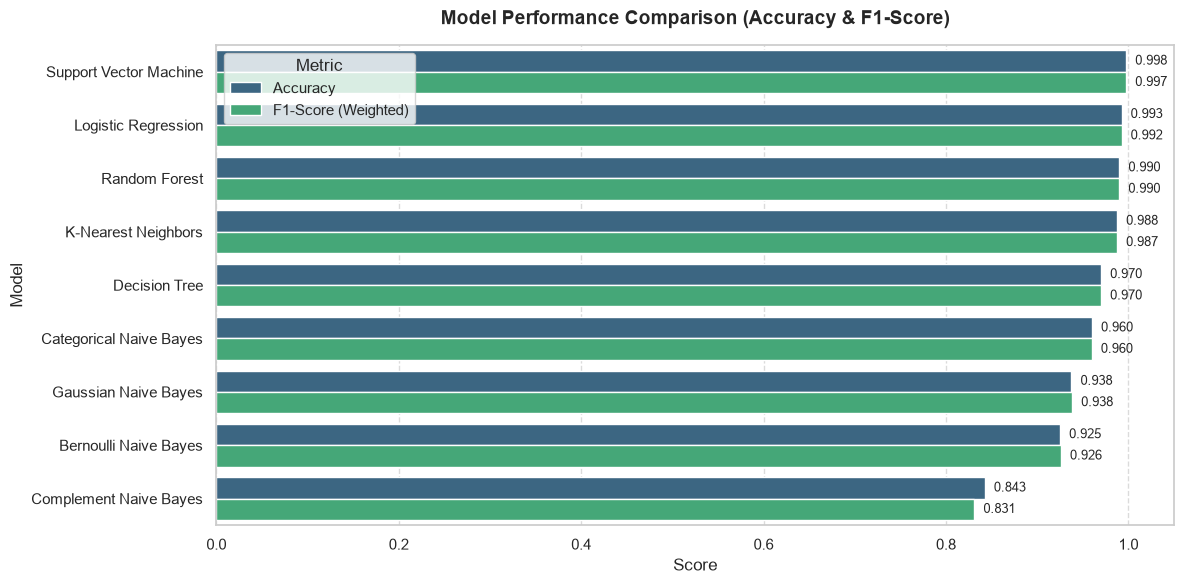

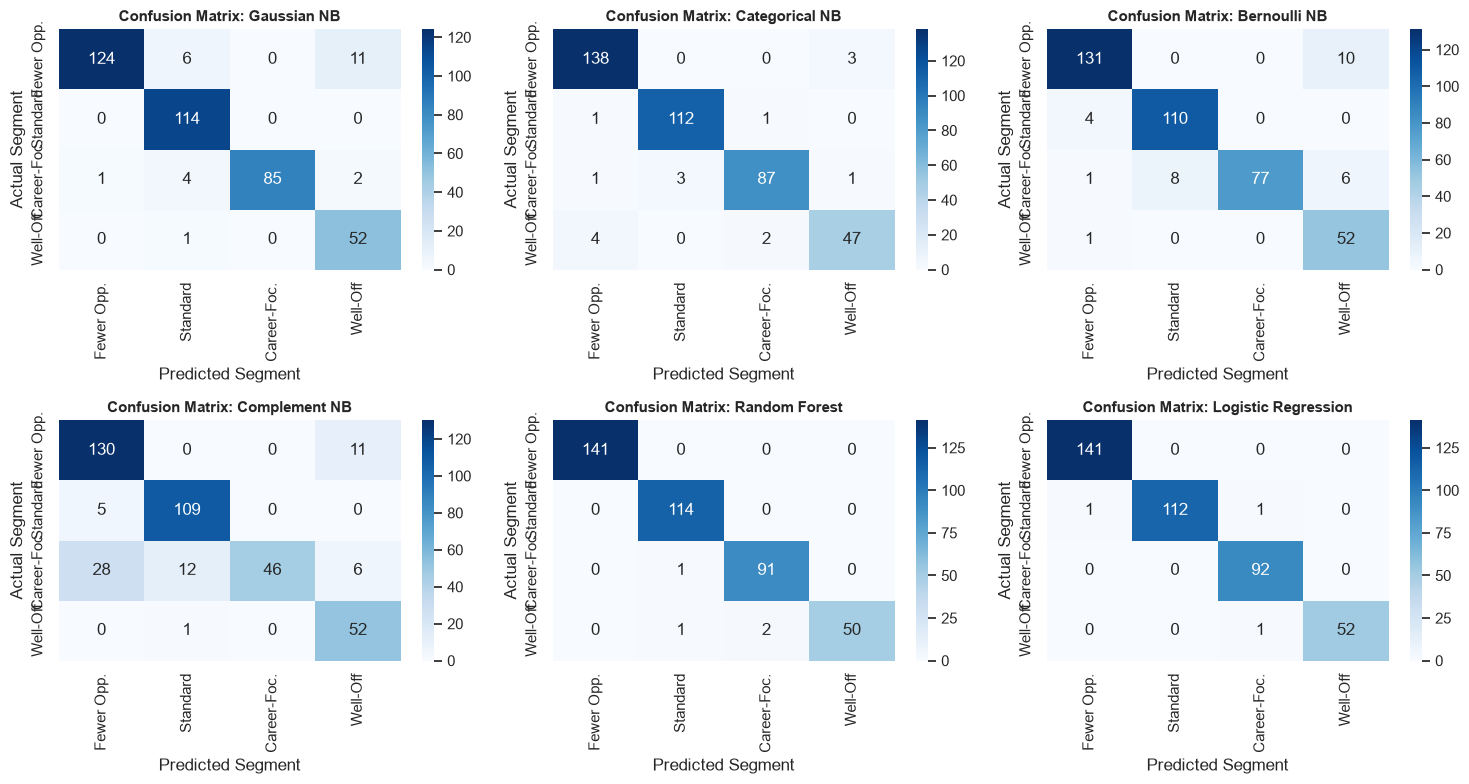

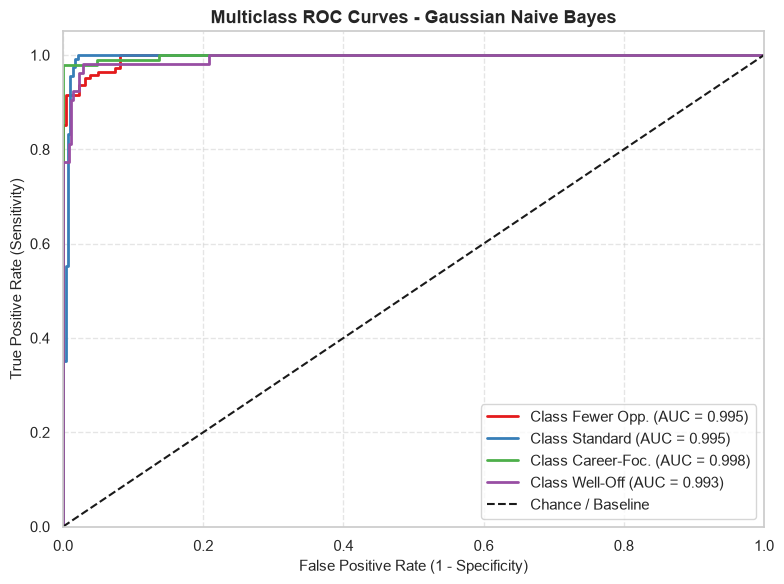

Artifact successfully saved to: artifacts/gaussian_nb_pipeline.joblib
Artifact successfully saved to: artifacts/categorical_nb_pipeline.joblib
Artifact successfully saved to: artifacts/best_model_pipeline.joblib
Metrics JSON saved to: artifacts/model_metrics.json
Top Model Saved: Support Vector Machine -> artifacts/best_model_pipeline.joblib

--- Production Pipeline Reload & Test Inference ---
Input Customer Profile: {'Sex': 1, 'Marital status': 1, 'Age': 24, 'Education': 1, 'Income': 125000, 'Occupation': 1, 'Settlement size': 0}
Predicted Segment:      Fewer Opportunities (ID: 0)
Class Probabilities:
  - Fewer Opportunities : 0.9992
  - Standard            : 0.0000
  - Career-Focused      : 0.0006
  - Well-Off            : 0.0002


In [7]:
# 1. Performance Comparison Bar Chart
fig_comp = plot_model_comparison(df_comparison)
plt.show()

# 2. Confusion Matrices for Naive Bayes Variants & Baselines
selected_models = {
    'Gaussian NB': tuned_pipelines['Gaussian Naive Bayes'],
    'Categorical NB': tuned_pipelines['Categorical Naive Bayes'],
    'Bernoulli NB': tuned_pipelines['Bernoulli Naive Bayes'],
    'Complement NB': tuned_pipelines['Complement Naive Bayes'],
    'Random Forest': tuned_pipelines['Random Forest'],
    'Logistic Regression': tuned_pipelines['Logistic Regression']
}
class_labels = ["Fewer Opp.", "Standard", "Career-Foc.", "Well-Off"]
fig_cm = plot_confusion_matrices(selected_models, X_test, y_test, class_names=class_labels)
plt.show()

# 3. Multiclass OvR ROC Curve for Gaussian Naive Bayes
gnb_model = tuned_pipelines['Gaussian Naive Bayes']
fig_roc = plot_multiclass_roc(gnb_model, X_test, y_test, model_name='Gaussian Naive Bayes', class_names=class_labels)
plt.show()

# 4. Save Artifacts
os.makedirs('artifacts', exist_ok=True)
save_pipeline_artifact(gnb_model, 'artifacts/gaussian_nb_pipeline.joblib')
save_pipeline_artifact(tuned_pipelines['Categorical Naive Bayes'], 'artifacts/categorical_nb_pipeline.joblib')

best_model_name = df_comparison.iloc[0]['Model']
best_model_pipeline = tuned_pipelines[best_model_name]
save_pipeline_artifact(best_model_pipeline, 'artifacts/best_model_pipeline.joblib')
save_metrics_json(evaluation_results, 'artifacts/model_metrics.json')

print(f"Top Model Saved: {best_model_name} -> artifacts/best_model_pipeline.joblib")

# 5. Production Inference Verification
print("\n--- Production Pipeline Reload & Test Inference ---")
reloaded_pipeline = load_pipeline_artifact('artifacts/best_model_pipeline.joblib')

sample_customer = {
    'Sex': 1,
    'Marital status': 1,
    'Age': 24,
    'Education': 1,
    'Income': 125000,
    'Occupation': 1,
    'Settlement size': 0
}

inference_result = predict_single_customer(reloaded_pipeline, sample_customer)
print(f"Input Customer Profile: {sample_customer}")
print(f"Predicted Segment:      {inference_result['Predicted_Segment_Name']} (ID: {inference_result['Predicted_Segment_ID']})")
print("Class Probabilities:")
for seg, prob in inference_result['Class_Probabilities'].items():
    print(f"  - {seg:20s}: {prob:.4f}")
